In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from sklearn.datasets import load_files
from pyvi import ViTokenizer
from sklearn import datasets
from sklearn import svm
from sklearn.svm import SVC
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import learning_curve,validation_curve
from sklearn.metrics import accuracy_score

%matplotlib inline

In [ ]:
%cd D:/du_lieu_huan_luyen

In [111]:
#Load dữ liệu và sinh từ điển cũng như từ dừng

In [112]:
data_train = load_files('news_vnexpress', encoding='utf8')
print(f'Tổng số file là : {len(data_train.filenames)}')
with open (file = 'vietnamese-stopwords.txt', encoding= 'utf8') as f:
    stopwords =  f.readlines()
stopwords = [x.strip().replace(" ","_") for x in stopwords]

model_count = CountVectorizer(stop_words=stopwords,max_df=0.8,min_df=2)
model_rf_preprocess = Pipeline([('vect',model_count),
                                ('tfidf',TfidfTransformer())])

data_preprocessed = model_rf_preprocess.fit_transform(data_train.data, data_train.target)
i = 0
for k,v in model_count.vocabulary_.items    ():
    print (f'{i} : ({k,v})')
    i = i + 1
    if (i > 10):
        break


Tổng số file là : 1339
0 : (('mời', 3518))
1 : (('độc', 6274))
2 : (('giả', 1988))
3 : (('câu', 1390))
4 : (('ảnh', 6306))
5 : (('trung', 5288))
6 : (('tâm', 5446))
7 : (('cấy', 1441))
8 : (('tóc', 5465))
9 : (('new', 3572))
10 : (('hair', 2148))


# Bài 1: Biến đổi văn bản sử dụng trực tiếp TFVectorizer() 

In [113]:
model_rf_preprocess = TfidfVectorizer(stop_words=stopwords)
data_preprocessed = model_rf_preprocess.fit_transform(data_train.data, data_train.target)
data_6 = model_rf_preprocess.transform([data_train.data[6]])

features_name = model_rf_preprocess.get_feature_names_out()
df = pd.DataFrame(data=data_6[0].T.todense(), index=features_name,columns=['tfidf'])
top10 = df.sort_values(by='tfidf', ascending=False).head(10)
print(top10)

                tfidf
trịnh        0.465507
lữ           0.405013
sách         0.197619
giả          0.192435
họa          0.160024
chép         0.159621
communities  0.151995
nghề         0.140276
rưng         0.129752
tiếng        0.128085


#Chia dữ liệu thành 2 phần train và test

In [114]:
X_train, X_test, y_train, y_test = train_test_split(data_preprocessed, data_train.target, test_size=0.2)
print(f'Kích cỡ của tập train: {X_train.shape}')
print(f'Kích cỡ của tập test: {X_test.shape}')
print("Danh sách nhãn và id tương ứng: ", [(idx, name) for idx, name in enumerate(data_train.target_names)] )

Kích cỡ của tập train: (1071, 12797)
Kích cỡ của tập test: (268, 12797)
Danh sách nhãn và id tương ứng:  [(0, 'doi-song'), (1, 'du-lich'), (2, 'giai-tri'), (3, 'giao-duc'), (4, 'khoa-hoc'), (5, 'kinh-doanh'), (6, 'phap-luat'), (7, 'suc-khoe'), (8, 'the-thao'), (9, 'thoi-su')]


#Training SVM Model với kernel = 'Linear'

In [115]:
model = svm.SVC(kernel='linear', C = 1.0)
model.fit(X_train,y_train)
print("training...complete")


training...complete


#Testing SVM Model

In [116]:
y_pred_test = model.predict(X_test)
acc = accuracy_score(y_test,y_pred_test)
print(f'Độ chính xác trên tập test: {acc}')
y_pred_train = model.predict(X_train)
acc = accuracy_score(y_train,y_pred_train)
print(f'Độ chính xác trên tập train: {acc}')

Độ chính xác trên tập test: 0.8955223880597015
Độ chính xác trên tập train: 1.0


#Training với kernel = 'rbf'

In [117]:
model = svm.SVC(kernel='rbf', C = 1.0)
model.fit(X_train,y_train)
print("training...complete")


training...complete


In [118]:
y_pred_test = model.predict(X_test)
acc = accuracy_score(y_test,y_pred_test)
print(f'Độ chính xác trên tập test: {acc}')
y_pred_train = model.predict(X_train)
acc = accuracy_score(y_train,y_pred_train)
print(f'Độ chính xác trên tập train: {acc}')

Độ chính xác trên tập test: 0.8283582089552238
Độ chính xác trên tập train: 1.0


#Sử dụng model đã train để infer 1 văn bản mới

In [119]:

new_doc = "Thể thao"
token = ViTokenizer.tokenize(new_doc)
token = model_rf_preprocess.transform([token])
y = model.predict(token)
print(f'Dự đoán nhãn mới là: {y}')

Dự đoán nhãn mới là: [2]


# Thử nghiệm lựa chọn siêu tham số

#Vẽ đường cong học tập khi tham số C thay đổi

In [ ]:
list_C = [0.001, 0.01, 0.1, 1, 5.0, 10.0, 100]
train_score, test_score = validation_curve(SVC(kernel = 'rbf'),X = data_preprocessed,y = data_train.target,
                                           param_name='C', 
                                           param_range=list_C,
                                           cv=5,
                                           scoring='accuracy',
                                           n_jobs=10)


<class 'numpy.ndarray'>


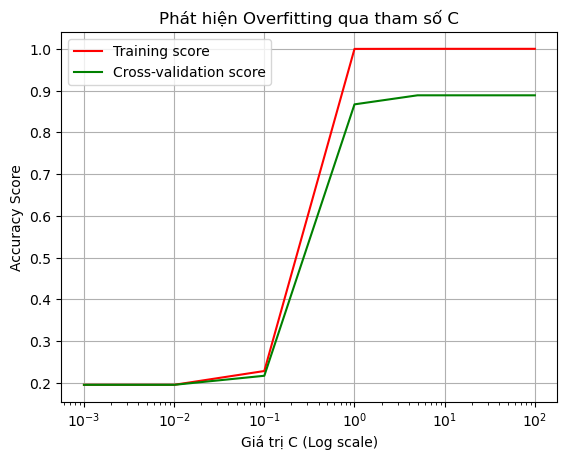

In [130]:
train_mean = np.mean(train_score,axis = 1)
test_mean = np.mean(test_score,axis = 1)
plt.semilogx(list_C, train_mean, label="Training score", color="r")
plt.semilogx(list_C, test_mean, label="Cross-validation score", color="g")

plt.title("Phát hiện Overfitting qua tham số C")
plt.xlabel("Giá trị C (Log scale)")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.grid()
plt.show()

#Dùng GridCv để tìm bộ tham số tốt nhất

In [ ]:

params_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100],
          'gamma': [0.0001, 0.001, 0.01, 0.1],
          'kernel':['linear','rbf', 'poly'] }
best_model = GridSearchCV(estimator=SVC(),param_grid=params_grid,cv = 5,
                          scoring='accuracy',
                          n_jobs=10)
best_model.fit(X_train,y_train)


In [139]:
#Đây là mô hình với các siêu tham số tốt nhất
final_model = best_model.best_estimator_
#Thử nghiệm
y_pred = final_model.predict(X_test)
print(accuracy_score(y_test,y_pred))

0.8917910447761194



# Thực hiện huấn luyện trên tập dữ liệu Digits

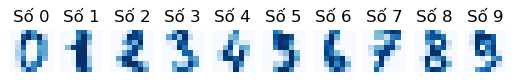

In [4]:
data_digit = datasets.load_digits()
data_digit.keys()
images_and_label = list(zip(data_digit.images,data_digit.target))
for index, (images, label) in enumerate (images_and_label[:10]):
    plt.subplot(2,10,index + 1)
    plt.axis('off')
    plt.imshow(images, cmap='Blues',interpolation='nearest')
    plt.title(f'Số {index}')

In [5]:
#Chia dữ liêu train-test
X_train,X_test,y_train,y_test = train_test_split(data_digit.data, data_digit.target, test_size = 0.2,random_state= 42)


In [6]:
#Xây dựng và huấn luyện mô hình để dự đoán hình ảnh
model = SVC(kernel= 'linear', C = 1)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
print(f'Độ chính xác trên tập test: {accuracy_score(y_test,y_pred)}')
y_pred = model.predict(X_train)
print(f'Độ chính xác trên tập train: {accuracy_score(y_train,y_pred)}')


Độ chính xác trên tập test: 0.9777777777777777
Độ chính xác trên tập train: 1.0


In [7]:
#Tìm siêu tham số cho mô hình

params_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'gamma': [0.0001, 0.001, 0.01, 0.1],
        'kernel':['linear','rbf', 'poly'] 
        }
best_model = GridSearchCV(estimator=SVC(), 
                          param_grid=params_grid,
                          n_jobs=-1,
                          scoring='accuracy',
                          cv=5)
best_model.fit(X_train,y_train)


,estimator,SVC()
,param_grid,"{'C': [0.001, 0.01, ...], 'gamma': [0.0001, 0.001, ...], 'kernel': ['linear', 'rbf', ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


In [11]:
#Chọn ra siêu tham số tốt nhất để đưa vào mô hình 
final_model = best_model.best_estimator_
y_pred = final_model.predict(X_test)
print(f'Siêu tham số của SVC:')
for param,value in final_model.get_params().items():
    print(f'{param}: {value}')

print(f'Độ chính xác trên tập test: {accuracy_score(y_test,y_pred)}')

Siêu tham số của SVC:
C: 10
break_ties: False
cache_size: 200
class_weight: None
coef0: 0.0
decision_function_shape: ovr
degree: 3
gamma: 0.001
kernel: rbf
max_iter: -1
probability: False
random_state: None
shrinking: True
tol: 0.001
verbose: False
Độ chính xác trên tập test: 0.9888888888888889
